In [21]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import yfinance as yf
# plt.style.use('fivethirtyeight')

In [22]:
# Getting the stock tickers for the portfolio

assets=['TCS','HDFCBANK','ITC','RELIANCE','IRCTC']

# Assigning weights

weights=np.array([0.2,0.2,0.2,0.2,0.2])

start_date='2020-01-01'
today=datetime.today().strftime('%Y-%m-%d')
today

'2024-09-08'

In [23]:
# Dataframe to store adjusted close prices of the assets

df=pd.DataFrame()
for stock in assets:
    df[stock]=yf.download(stock+'.NS',start=start_date,end=today)['Adj Close']

df

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,TCS,HDFCBANK,ITC,RELIANCE,IRCTC
Date,,,,,
2020-01-01,1980.293091,1227.428589,194.749054,1356.042725,183.362961
2020-01-02,1971.202881,1235.252441,196.180435,1379.128540,180.654312
2020-01-03,2010.486572,1217.636841,195.076218,1380.790405,180.848495
2020-01-06,2010.303955,1191.285400,192.295273,1348.766968,173.673965
2020-01-07,2015.237549,1210.148926,192.499741,1369.517090,176.188431
...,...,...,...,...,...
2024-09-02,4521.049805,1626.949951,510.049988,3032.500000,937.000000
2024-09-03,4512.350098,1637.349976,509.399994,3018.250000,944.150024
2024-09-04,4479.250000,1641.800049,506.350006,3029.100098,939.200012


In [24]:
# Check for missing data
print(df.isnull().sum())

# Fill missing data using forward fill
df.fillna(method='ffill', inplace=True)  # Forward fill
print(df.isnull().sum())

TCS         0
HDFCBANK    0
ITC         0
RELIANCE    0
IRCTC       0
dtype: int64
TCS         0
HDFCBANK    0
ITC         0
RELIANCE    0
IRCTC       0
dtype: int64


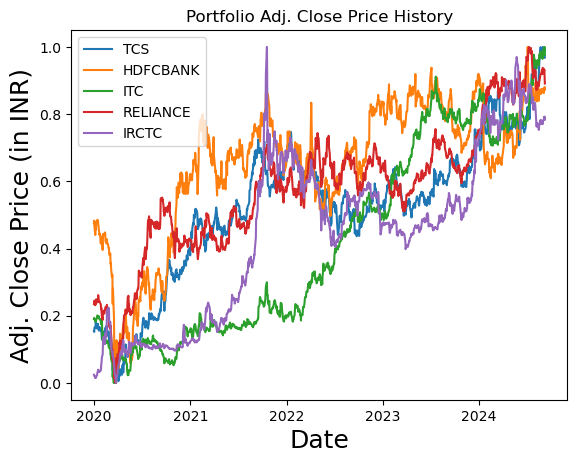

In [25]:
# Normalizing the data

df_normalized = (df - df.min()) / (df.max() - df.min())

# Plotting the stocks

title='Portfolio Adj. Close Price History'
my_stocks=df_normalized
for col in my_stocks.columns.values:
    plt.plot(my_stocks[col],label=col)

plt.title(title)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Adj. Close Price (in INR)',fontsize=18)
plt.legend(my_stocks.columns.values,loc='upper left')
plt.show()

In [26]:
# Daily returns

returns=df.pct_change().dropna()
returns

,TCS,HDFCBANK,ITC,RELIANCE,IRCTC
Date,,,,,
2020-01-02,-0.004590,0.006374,0.007350,0.017024,-0.014772
2020-01-03,0.019929,-0.014261,-0.005629,0.001205,0.001075
2020-01-06,-0.000091,-0.021641,-0.014256,-0.023192,-0.039671
2020-01-07,0.002454,0.015835,0.001063,0.015385,0.014478
2020-01-08,0.022395,-0.002618,-0.004886,-0.007510,-0.012398
...,...,...,...,...,...
2024-09-02,-0.007181,-0.006079,0.016238,0.004389,0.004503
2024-09-03,-0.001924,0.006392,-0.001274,-0.004699,0.007631
2024-09-04,-0.007335,0.002718,-0.005987,0.003595,-0.005243


In [27]:
# Annualized covariance matrix

cov_matrix_annual=returns.cov()*252
cov_matrix_annual

,TCS,HDFCBANK,ITC,RELIANCE,IRCTC
TCS,0.061152,0.022075,0.015848,0.028676,0.016278
HDFCBANK,0.022075,0.076858,0.021485,0.037080,0.028185
ITC,0.015848,0.021485,0.069435,0.024021,0.023480
RELIANCE,0.028676,0.037080,0.024021,0.091456,0.032606
IRCTC,0.016278,0.028185,0.023480,0.032606,0.166403


In [28]:
# Portfolio variance

port_variance=np.dot(weights.T,np.dot(cov_matrix_annual,weights))
port_variance

0.0385908672613309

In [29]:
# Calculating the portfolio volatility/standard deviation

port_volatility=np.sqrt(port_variance)
port_volatility

0.1964455834609954

In [30]:
# Calculating annual portfolio return

port_ret=np.sum(returns.mean()*weights)*252
port_ret

0.23998991161626598

In [31]:
# Expected annual return, volatility, variance


percent_var=str(round(port_variance,2)*100)+'%'
percent_volt=str(round(port_volatility,2)*100)+'%'
percent_ret=str(round(port_ret,2)*100)+'%'

print('Expected Annual Return = '+percent_ret)
print('Annual Volatility (risk) = '+percent_volt)
print('Annual Variance = '+percent_var)

Expected Annual Return = 24.0%
Annual Volatility (risk) = 20.0%
Annual Variance = 4.0%


In [32]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

In [33]:
# OPTIMIZATION

mu=expected_returns.mean_historical_return(df)   
S=risk_models.sample_cov(df)  # annualized sample covariance matrix

# Optimizing for max Sharpe Ratio

ef=EfficientFrontier(mu,S)
weights=ef.max_sharpe()
cleaned_weights=ef.clean_weights()
print(cleaned_weights)
ef.portfolio_performance(verbose=True)

OrderedDict([('TCS', 0.31534), ('HDFCBANK', 0.0), ('ITC', 0.33599), ('RELIANCE', 0.0), ('IRCTC', 0.34866)])
Expected annual return: 28.6%
Annual volatility: 21.6%
Sharpe Ratio: 1.23


(0.28595424529208724, 0.21584151374660335, 1.232173740239405)

In [34]:
# Getting discrete allocation of each share per stock

from pypfopt.discrete_allocation import DiscreteAllocation,get_latest_prices

latest_prices=get_latest_prices(df)
weights=cleaned_weights
da=DiscreteAllocation(weights,latest_prices,total_portfolio_value=100000)
allocation,leftover=da.lp_portfolio()
print('Discrete Allocation: ',allocation)
print('Funds remaining: Rs. {:.2f}'.format(leftover))

Discrete Allocation:  {'TCS': 7, 'ITC': 67, 'IRCTC': 37}
Funds remaining: Rs. 538.35
